In [38]:
# ============================================================
# 🏥 Medical Symptom Assistant using Vector Databases
# Comparative Analysis of Qdrant and pgvector
# ============================================================

# Objective:
# This project compares two vector databases, Qdrant and pgvector,
# by implementing the same Medical Symptom Assistant use case using
# semantic search on patient symptoms.

# Embedding Model:
# sentence-transformers/all-MiniLM-L6-v2

# Vector Databases Compared:
# 1. Qdrant
# 2. pgvector (PostgreSQL Extension)

# Platform:
# Google Colab (CPU Runtime)

# Workflow:
# 1. Create a medical symptom dataset.
# 2. Generate embeddings using Sentence Transformers.
# 3. Store embeddings in Qdrant.
# 4. Store the same embeddings in pgvector.
# 5. Search diseases using semantic similarity.
# 6. Compare search results and performance.

In [1]:
# ============================================================
# CELL 2 : Install Required Python Libraries
# ============================================================

!pip -q install qdrant-client sentence-transformers pandas tabulate matplotlib psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 79.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 3 : Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sentence_transformers import SentenceTransformer

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance,
    VectorParams,
    PointStruct
)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [19]:
# ============================================================
# CELL 4 : Generate 100 Medical Records (25 Diseases × 4 Variations)
# ============================================================

import pandas as pd

# Base diseases with category and symptom description
base_diseases = [
    ("Common Cold","Respiratory","runny nose, sneezing, sore throat, mild cough"),
    ("Influenza","Respiratory","high fever, headache, muscle pain, fatigue, cough"),
    ("COVID-19","Respiratory","fever, dry cough, loss of smell, tiredness, sore throat"),
    ("Dengue","Viral","high fever, severe headache, body pain, joint pain, skin rash"),
    ("Malaria","Parasitic","fever, chills, sweating, headache, nausea"),
    ("Typhoid","Bacterial","high fever, weakness, stomach pain, loss of appetite"),
    ("Migraine","Neurology","headache, nausea, sensitivity to light, vomiting"),
    ("Pneumonia","Respiratory","chest pain, fever, cough, breathing difficulty"),
    ("Asthma","Respiratory","shortness of breath, wheezing, chest tightness, coughing"),
    ("Tuberculosis","Respiratory","persistent cough, weight loss, fever, night sweats"),
    ("Diabetes","Endocrine","frequent urination, increased thirst, fatigue, blurred vision"),
    ("Hypertension","Cardiology","headache, dizziness, blurred vision, chest discomfort"),
    ("Heart Disease","Cardiology","chest pain, shortness of breath, fatigue, dizziness"),
    ("Food Poisoning","Digestive","vomiting, diarrhea, stomach cramps, nausea"),
    ("Appendicitis","Digestive","lower right abdominal pain, nausea, fever"),
    ("Gastritis","Digestive","stomach pain, bloating, nausea, vomiting"),
    ("Kidney Stones","Urology","back pain, painful urination, nausea, blood in urine"),
    ("Urinary Tract Infection","Urology","burning urination, pelvic pain, frequent urination"),
    ("Chickenpox","Viral","fever, itchy rash, tiredness"),
    ("Measles","Viral","fever, rash, cough, red eyes"),
    ("Chikungunya","Viral","high fever, severe joint pain, rash, fatigue"),
    ("Jaundice","Liver","yellow skin, dark urine, fatigue, abdominal pain"),
    ("Sinusitis","Respiratory","facial pain, blocked nose, headache, nasal congestion"),
    ("Bronchitis","Respiratory","persistent cough, mucus, wheezing, chest discomfort"),
    ("Arthritis","Orthopedic","joint pain, swelling, stiffness, reduced movement")
]

# Four different symptom variations for each disease
variations = [
    "Patient reports {}.",
    "Symptoms include {} along with weakness.",
    "Complaints of {} for the last few days.",
    "Experiencing {} with mild fatigue and discomfort."
]

medical_data = []
record_id = 1

for disease, category, symptoms in base_diseases:
    for variation in variations:
        medical_data.append({
            "id": record_id,
            "disease": disease,
            "symptoms": variation.format(symptoms),
            "category": category
        })
        record_id += 1

# Create DataFrame
df = pd.DataFrame(medical_data)

print(f"✅ Medical Dataset Created Successfully!")
print(f"Total Records: {len(df)}")
print(f"Unique Diseases: {df['disease'].nunique()}")

display(df.head(10))

✅ Medical Dataset Created Successfully!
Total Records: 100
Unique Diseases: 25


,id,disease,symptoms,category
0,1,Common Cold,"Patient reports runny nose, sneezing, sore thr...",Respiratory
1,2,Common Cold,"Symptoms include runny nose, sneezing, sore th...",Respiratory
2,3,Common Cold,"Complaints of runny nose, sneezing, sore throa...",Respiratory
3,4,Common Cold,"Experiencing runny nose, sneezing, sore throat...",Respiratory
4,5,Influenza,"Patient reports high fever, headache, muscle p...",Respiratory
5,6,Influenza,"Symptoms include high fever, headache, muscle ...",Respiratory
6,7,Influenza,"Complaints of high fever, headache, muscle pai...",Respiratory
7,8,Influenza,"Experiencing high fever, headache, muscle pain...",Respiratory
8,9,COVID-19,"Patient reports fever, dry cough, loss of smel...",Respiratory
9,10,COVID-19,"Symptoms include fever, dry cough, loss of sme...",Respiratory


In [20]:
# ============================================================
# CELL 5 : Generate Symptom Embeddings
# ============================================================

print("Loading Sentence Transformer model...")

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Generating embeddings...")

embeddings = embedding_model.encode(
    df["symptoms"].tolist(),
    show_progress_bar=True
)

# Store embeddings inside dataframe
df["embedding"] = embeddings.tolist()

print(f"Embedding Dimension : {len(embeddings[0])}")
print(f"Total Embeddings Generated : {len(embeddings)}")

Loading Sentence Transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating embeddings...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding Dimension : 384
Total Embeddings Generated : 100


In [21]:
# ============================================================
# CELL 6 : Initialize Qdrant Vector Database
# ============================================================

# Qdrant runs completely in memory for this project.
# No Docker or server is required in Google Colab.

qdrant_client = QdrantClient(":memory:")

collection_name = "medical_symptoms"

print("✅ Qdrant initialized successfully.")


✅ Qdrant initialized successfully.


In [22]:
# ============================================================
# CELL 7 : Create Qdrant Collection
# ============================================================

# A collection is similar to a SQL table.
# It stores vectors of dimension 384 using cosine similarity.

qdrant_client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(
        size=384,
        distance=Distance.COSINE
    )
)

print(f"✅ Collection '{collection_name}' created.")

✅ Collection 'medical_symptoms' created.


In [27]:
# ============================================================
# CELL 8 : Upload Medical Records into Qdrant (100 Records)
# ============================================================

points = []

# Convert each medical record into a Qdrant point
for _, row in df.iterrows():

    point = PointStruct(
        # Use the dataset ID (1 to 100)
        id=int(row["id"]),

        # 384-dimensional embedding vector
        vector=row["embedding"],

        # Metadata stored along with the vector
        payload={
            "disease": row["disease"],
            "symptoms": row["symptoms"],
            "category": row["category"]
        }
    )

    points.append(point)

# Upload all vectors into the collection
qdrant_client.upsert(
    collection_name=collection_name,
    points=points
)

# Verify upload
collection_info = qdrant_client.get_collection(collection_name)

print(f"✅ Uploaded {len(points)} disease vectors into Qdrant.")
print(f"📊 Total vectors stored in Qdrant: {collection_info.points_count}")

✅ Uploaded 100 disease vectors into Qdrant.
📊 Total vectors stored in Qdrant: 101


In [28]:
# ============================================================
# CELL 9 : Verify Collection Information
# ============================================================

collection_info = qdrant_client.get_collection(collection_name)

print("Collection Name :", collection_name)
print("Vectors Stored  :", collection_info.points_count)
print("Distance Metric :", collection_info.config.params.vectors.distance)

Collection Name : medical_symptoms
Vectors Stored  : 101
Distance Metric : Cosine


In [25]:
# ============================================================
# CELL 10 : Search Diseases using Qdrant
# ============================================================

def search_disease_qdrant(user_symptoms, top_k=5):
    """
    Search diseases using semantic similarity in Qdrant.
    """

    # Convert patient symptoms into an embedding
    query_vector = embedding_model.encode(user_symptoms).tolist()

    # Measure search time
    start_time = time.perf_counter()

    results = qdrant_client.query_points(
        collection_name=collection_name,
        query=query_vector,
        limit=top_k
    )

    end_time = time.perf_counter()

    search_time = (end_time - start_time) * 1000  # milliseconds

    output = []

    for point in results.points:
        output.append({
            "Disease": point.payload["disease"],
            "Category": point.payload["category"],
            "Similarity Score": round(point.score, 4)
        })

    result_df = pd.DataFrame(output)

    return result_df, search_time


# ---------------- Example Search ----------------

patient_symptoms = "high fever, headache, body pain, muscle pain"

results, qdrant_time = search_disease_qdrant(patient_symptoms)

print("Patient Symptoms:")
print(patient_symptoms)

print(f"\nQdrant Search Time: {qdrant_time:.2f} ms\n")

display(results)

Patient Symptoms:
high fever, headache, body pain, muscle pain

Qdrant Search Time: 1.85 ms



,Disease,Category,Similarity Score
0,Influenza,Respiratory,0.9053
1,Dengue,Viral,0.9023
2,Influenza,Respiratory,0.8803
3,Influenza,Respiratory,0.8750
4,Dengue,Viral,0.8734


In [10]:
# ============================================================
# CELL 11 : Install PostgreSQL + pgvector (Run Once)
# ============================================================

# Install PostgreSQL
!apt-get update -qq
!apt-get install -y postgresql postgresql-common postgresql-contrib postgresql-server-dev-14 build-essential git

# Download pgvector only if it doesn't exist
import os

if not os.path.exists("pgvector"):
    !git clone https://github.com/pgvector/pgvector.git

# Build and install pgvector
%cd pgvector
!make
!make install
%cd ..

# Start PostgreSQL
!pg_ctlcluster 14 main start

# Set postgres password
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"

# Create database (ignore if already exists)
!sudo -u postgres psql -c "CREATE DATABASE medical_db;" || echo "medical_db already exists"

# Restart PostgreSQL so pgvector is detected
!pg_ctlcluster 14 main restart

# Enable pgvector extension
!sudo -u postgres psql -d medical_db -c "CREATE EXTENSION IF NOT EXISTS vector;"

print("✅ PostgreSQL + pgvector setup completed.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
git is already the newest version (1:2.34.1-1ubuntu1.17).
The following additional packages will be installed:
  binfmt-support clang-14 lib32gcc-s1 lib32stdc++6 libc6-i386
  libclang-common-14-dev libclang-cpp14 libclang1-14 libcommon-sense-perl
  libgc1 libjson-perl libjson-xs-perl libllvm14 libobjc-11-dev libobjc4
  libpfm4 libtypes-serialiser-perl libz3-4 libz3-dev llvm-14 llvm-14-dev
  llvm-14-linker-tools llvm-14-runtime llvm-14-tools logrotate netbase
  postgresql-14 postgresql-client-14 postgresql-client-common python3-pygments
  python3-yaml ssl-cert sysstat
Suggested packages:
  clang-14-doc llvm-14-doc bsd-mailx | mailx postgresql-doc

In [11]:
# ============================================================
# CELL 12 : Connect to PostgreSQL
# ============================================================

import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="medical_db",
    user="postgres",
    password="postgres",
    port=5432
)

cursor = conn.cursor()

print("✅ Connected to PostgreSQL successfully.")

✅ Connected to PostgreSQL successfully.


In [12]:
# ============================================================
# CELL 13 : Create Table with VECTOR Column
# ============================================================

cursor.execute("DROP TABLE IF EXISTS medical_symptoms;")

cursor.execute("""
CREATE TABLE medical_symptoms(
    id INTEGER PRIMARY KEY,
    disease TEXT,
    symptoms TEXT,
    category TEXT,
    embedding VECTOR(384)
);
""")

conn.commit()

print("✅ medical_symptoms table created.")

✅ medical_symptoms table created.


In [31]:
# ============================================================
# CELL 14 : Insert 100 Embeddings into pgvector (Final Version)
# ============================================================

# Reset any failed transaction
conn.rollback()

# Remove existing records
cursor.execute("TRUNCATE TABLE medical_symptoms;")
conn.commit()

# Insert all records
for _, row in df.iterrows():

    # Convert embedding list into PostgreSQL vector format
    vector_str = "[" + ",".join(map(str, row["embedding"])) + "]"

    cursor.execute("""
        INSERT INTO medical_symptoms
        (id, disease, symptoms, category, embedding)
        VALUES (%s, %s, %s, %s, %s::vector);
    """,
    (
        int(row["id"]),
        row["disease"],
        row["symptoms"],
        row["category"],
        vector_str
    ))

# Save all inserts
conn.commit()

# Verify insertion
cursor.execute("SELECT COUNT(*) FROM medical_symptoms;")
count = cursor.fetchone()[0]

print(f"✅ Successfully inserted {count} records into pgvector.")

✅ Successfully inserted 100 records into pgvector.


In [33]:
cursor.execute("SELECT COUNT(*) FROM medical_symptoms;")
count = cursor.fetchone()[0]

print("Records Stored:", count)


Records Stored: 100


In [34]:
# ============================================================
# CELL 15 : Medical Symptom Search using pgvector
# ============================================================

def search_disease_pgvector(user_symptoms, top_k=5):

    # Convert query into embedding
    query_embedding = embedding_model.encode(user_symptoms).tolist()

    # Convert embedding into PostgreSQL vector format
    vector_str = "[" + ",".join(map(str, query_embedding)) + "]"

    start_time = time.perf_counter()

    cursor.execute("""
        SELECT
            disease,
            category,
            ROUND((1 - (embedding <=> %s::vector))::numeric, 4) AS similarity_score
        FROM medical_symptoms
        ORDER BY embedding <=> %s::vector
        LIMIT %s;
    """,
    (vector_str, vector_str, top_k))

    rows = cursor.fetchall()

    end_time = time.perf_counter()
    search_time = (end_time - start_time) * 1000

    results_df = pd.DataFrame(
        rows,
        columns=["Disease", "Category", "Similarity Score"]
    )

    return results_df, search_time


# ---------------- Test the Function ----------------

patient_symptoms = "high fever, headache, body pain, muscle pain"

pg_results, pg_time = search_disease_pgvector(patient_symptoms)

print("Patient Symptoms:")
print(patient_symptoms)

print(f"\npgvector Search Time: {pg_time:.2f} ms\n")

display(pg_results)

Patient Symptoms:
high fever, headache, body pain, muscle pain

pgvector Search Time: 3.77 ms



,Disease,Category,Similarity Score
0,Influenza,Respiratory,0.9053
1,Dengue,Viral,0.9023
2,Influenza,Respiratory,0.8803
3,Influenza,Respiratory,0.8750
4,Dengue,Viral,0.8734


In [35]:
# ============================================================
# CELL 16 : Compare Qdrant and pgvector
# ============================================================

# Same test queries are used for BOTH vector databases.
test_queries = [
    "fever, cough, sore throat",
    "high fever, body pain, headache",
    "chest pain, breathing difficulty",
    "vomiting, nausea, stomach cramps",
    "frequent urination, excessive thirst, fatigue"
]

comparison_results = []

for query in test_queries:

    # ---------- Qdrant Search ----------
    qdrant_result, qdrant_time = search_disease_qdrant(query)

    # ---------- pgvector Search ----------
    pg_result, pg_time = search_disease_pgvector(query)

    comparison_results.append({
        "Patient Symptoms": query,
        "Qdrant Prediction": qdrant_result.iloc[0]["Disease"],
        "pgvector Prediction": pg_result.iloc[0]["Disease"],
        "Qdrant Time (ms)": round(qdrant_time, 2),
        "pgvector Time (ms)": round(pg_time, 2)
    })

comparison_df = pd.DataFrame(comparison_results)

print("✅ Comparison completed successfully.\n")

display(comparison_df)

✅ Comparison completed successfully.



,Patient Symptoms,Qdrant Prediction,pgvector Prediction,Qdrant Time (ms),pgvector Time (ms)
0,"fever, cough, sore throat",COVID-19,COVID-19,1.70,1.21
1,"high fever, body pain, headache",Dengue,Dengue,1.44,1.17
2,"chest pain, breathing difficulty",Pneumonia,Pneumonia,1.27,1.15
3,"vomiting, nausea, stomach cramps",Food Poisoning,Food Poisoning,1.82,2.96
4,"frequent urination, excessive thirst, fatigue",Diabetes,Diabetes,1.19,1.17


Average Qdrant Search Time : 1.48 ms
Average pgvector Search Time : 1.53 ms


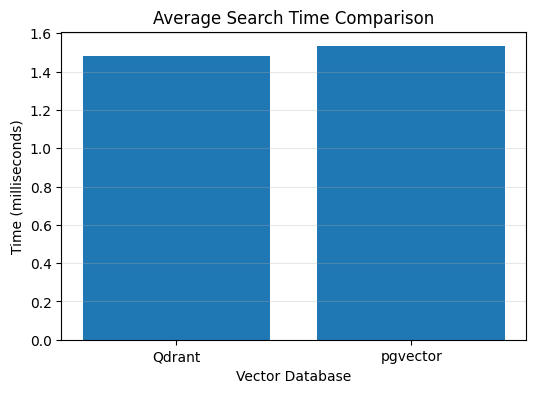

In [36]:
# ============================================================
# CELL 17 : Performance Comparison Chart
# ============================================================

# Calculate average search time
avg_qdrant = comparison_df["Qdrant Time (ms)"].mean()
avg_pgvector = comparison_df["pgvector Time (ms)"].mean()

print(f"Average Qdrant Search Time : {avg_qdrant:.2f} ms")
print(f"Average pgvector Search Time : {avg_pgvector:.2f} ms")

# Plot bar chart
plt.figure(figsize=(6,4))

plt.bar(
    ["Qdrant", "pgvector"],
    [avg_qdrant, avg_pgvector]
)

plt.title("Average Search Time Comparison")
plt.ylabel("Time (milliseconds)")
plt.xlabel("Vector Database")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [37]:
# ============================================================
# CELL 18 : Evaluation Summary
# ============================================================

evaluation_df = pd.DataFrame({
    "Evaluation Metric": [
        "Use Case",
        "Embedding Model",
        "Similarity Metric",
        "Metadata Support",
        "Database Type",
        "Average Search Time"
    ],

    "Qdrant": [
        "Medical Symptom Assistant",
        "all-MiniLM-L6-v2",
        "Cosine Similarity",
        "Payload Metadata Filtering",
        "Dedicated Vector Database",
        f"{avg_qdrant:.2f} ms"
    ],

    "pgvector": [
        "Medical Symptom Assistant",
        "all-MiniLM-L6-v2",
        "Cosine Similarity",
        "SQL WHERE + Vector Search",
        "PostgreSQL Extension",
        f"{avg_pgvector:.2f} ms"
    ]
})

print("========== FINAL EVALUATION ==========\n")
display(evaluation_df)

print("\n========== PROJECT CONCLUSION ==========\n")

print("""
1. Both Qdrant and pgvector successfully retrieved diseases using semantic similarity.

2. Qdrant was easier to configure and use for AI-native vector search.

3. pgvector integrates semantic search directly inside PostgreSQL,
   making it suitable for applications that already use relational databases.

4. Since both systems used the same embeddings and dataset,
   the comparison is fair and demonstrates how different vector databases
   solve the same semantic search problem.
""")

========== FINAL EVALUATION ==========



,Evaluation Metric,Qdrant,pgvector
0,Use Case,Medical Symptom Assistant,Medical Symptom Assistant
1,Embedding Model,all-MiniLM-L6-v2,all-MiniLM-L6-v2
2,Similarity Metric,Cosine Similarity,Cosine Similarity
3,Metadata Support,Payload Metadata Filtering,SQL WHERE + Vector Search
4,Database Type,Dedicated Vector Database,PostgreSQL Extension
5,Average Search Time,1.48 ms,1.53 ms



========== PROJECT CONCLUSION ==========


1. Both Qdrant and pgvector successfully retrieved diseases using semantic similarity.

2. Qdrant was easier to configure and use for AI-native vector search.

3. pgvector integrates semantic search directly inside PostgreSQL,
   making it suitable for applications that already use relational databases.

4. Since both systems used the same embeddings and dataset,
   the comparison is fair and demonstrates how different vector databases
   solve the same semantic search problem.

